## Importing Library

In [1]:
import pandas as pd

In [2]:
import numpy as np

## Loading breast cancer dataset

In [3]:
df = pd.read_csv('breast-cancer.csv',header=None)

In [4]:
df.columns = ['Class',
'age',
'menopause',
'tumor-size',
'inv-nodes',
'node-caps',
'deg-malig',
'breast',
'breast-quad',
'irradiat']



#1.Class: no-recurrence-events, recurrence-events
#2. age: 10-19, 20-29, 30-39, 40-49, 50-59, 60-69, 70-79, 80-89, 90-99.
#3. menopause: lt40, ge40, premeno.
#4. tumor-size: 0-4, 5-9, 10-14, 15-19, 20-24, 25-29, 30-34, 35-39, 40-44, 45-49, 50-54, 55-59.
#5. inv-nodes: 0-2, 3-5, 6-8, 9-11, 12-14, 15-17, 18-20, 21-23, 24-26, 27-29, 30-32, 33-35, 36-39.
#6. node-caps: yes, no.
#7. deg-malig: 1, 2, 3.
#8. breast: left, right.
#9. breast-quad: left-up, left-low, right-up, right-low, central.
#10. irradiat: yes, no.

## Data View

In [5]:
df.head()

,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class        286 non-null    object
 1   age          286 non-null    object
 2   menopause    286 non-null    object
 3   tumor-size   286 non-null    object
 4   inv-nodes    286 non-null    object
 5   node-caps    286 non-null    object
 6   deg-malig    286 non-null    int64 
 7   breast       286 non-null    object
 8   breast-quad  286 non-null    object
 9   irradiat     286 non-null    object
dtypes: int64(1), object(9)
memory usage: 22.5+ KB


## Data Organization

In [7]:
df['node-caps'].value_counts()

no     222
yes     56
?        8
Name: node-caps, dtype: int64

In [8]:
df['node-caps'].mask(df['node-caps']=='?',1, inplace=True)

In [9]:
df.loc[df['Class']=='no-recurrence-events', "Class"] = 0
df.loc[df['Class']=='recurrence-events', "Class"] = 1

In [10]:
df.loc[df['age']=='20-29','age'] = 0
df.loc[df['age']=='30-39','age'] = 1
df.loc[df['age']=='40-49','age'] = 2
df.loc[df['age']=='50-59','age'] = 3
df.loc[df['age']=='60-69','age'] = 4
df.loc[df['age']=='70-79','age'] = 5

In [11]:
df.loc[df['menopause']=='premeno','menopause'] = 0
df.loc[df['menopause']=='ge40','menopause'] = 1
df.loc[df['menopause']=='lt40','menopause'] = 2

In [12]:
df.loc[df['tumor-size']=='0-4','tumor-size'] = 0
df.loc[df['tumor-size']=='5-9','tumor-size'] = 1
df.loc[df['tumor-size']=='10-14','tumor-size'] = 2
df.loc[df['tumor-size']=='15-19','tumor-size'] = 3
df.loc[df['tumor-size']=='20-24','tumor-size'] = 4
df.loc[df['tumor-size']=='25-29','tumor-size'] = 5
df.loc[df['tumor-size']=='30-34','tumor-size'] = 6
df.loc[df['tumor-size']=='35-39','tumor-size'] = 7
df.loc[df['tumor-size']=='40-44','tumor-size'] = 8
df.loc[df['tumor-size']=='45-49','tumor-size'] = 9
df.loc[df['tumor-size']=='50-54','tumor-size'] = 10

In [13]:
df.loc[df['inv-nodes'] == '0-2','inv-nodes'] = 0
df.loc[df['inv-nodes'] == '3-5','inv-nodes'] = 1
df.loc[df['inv-nodes'] == '6-8','inv-nodes'] = 2
df.loc[df['inv-nodes'] == '9-11','inv-nodes'] = 3
df.loc[df['inv-nodes'] == '12-14','inv-nodes'] = 4
df.loc[df['inv-nodes'] == '15-17','inv-nodes'] = 5
df.loc[df['inv-nodes'] == '24-26','inv-nodes'] = 6

In [14]:
df.loc[df['node-caps']=='no','node-caps'] = 0
df.loc[df['node-caps']=='yes','node-caps'] = 1
df.loc[df['node-caps']=='?','node-caps'] = 2

In [15]:
df.loc[df['breast']=='left','breast'] = 0
df.loc[df['breast']=='right','breast'] = 1

In [16]:
df['breast-quad'].mask(df['breast-quad']=='?',0, inplace=True)
df.loc[df['breast-quad']=='left_low','breast-quad'] = 0
df.loc[df['breast-quad']=='left_up','breast-quad'] = 1
df.loc[df['breast-quad']=='right_up','breast-quad'] = 2
df.loc[df['breast-quad']=='right_low','breast-quad'] = 3
df.loc[df['breast-quad']=='central','breast-quad'] = 4

In [17]:
df.loc[df['irradiat']=='no','irradiat'] = 0
df.loc[df['irradiat']=='yes','irradiat'] = 1

In [18]:
df.head()

,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,0,1,0,6,0,0,3,0,0,0
1,0,2,0,4,0,0,2,1,2,0
2,0,2,0,4,0,0,2,0,0,0
3,0,4,1,3,0,0,2,1,1,0
4,0,2,0,0,0,0,2,1,3,0


In [19]:
df['irradiat'].value_counts()

0    218
1     68
Name: irradiat, dtype: int64

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class        286 non-null    object
 1   age          286 non-null    object
 2   menopause    286 non-null    object
 3   tumor-size   286 non-null    object
 4   inv-nodes    286 non-null    object
 5   node-caps    286 non-null    object
 6   deg-malig    286 non-null    int64 
 7   breast       286 non-null    object
 8   breast-quad  286 non-null    object
 9   irradiat     286 non-null    object
dtypes: int64(1), object(9)
memory usage: 22.5+ KB


## X and y differentiate

In [21]:
y = df.iloc[:,9]
y = y.astype('int64')
y

0      0
1      0
2      0
3      0
4      0
      ..
281    0
282    1
283    0
284    0
285    0
Name: irradiat, Length: 286, dtype: int64

In [22]:
X = df.iloc[:,[0,2,6]]
X = X.astype('int64')
X

,Class,menopause,deg-malig
0,0,0,3
1,0,0,2
2,0,0,2
3,0,1,2
4,0,0,2
...,...,...,...
281,1,0,2
282,1,0,3
283,1,1,1
284,1,1,3


## Importing sklearn

In [24]:
from sklearn.model_selection import train_test_split

**Test Train Split**

In [25]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, random_state=0)

**Importing and Running DecisionTreeClassifier**

In [26]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

In [76]:
clf = tree.DecisionTreeClassifier(max_depth = 5, 
                             random_state = 0)

In [77]:
clf = clf.fit(X_train, Y_train)

[Text(172.63125000000002, 199.32, 'X[0] <= 0.5\ngini = 0.363\nsamples = 214\nvalue = [163, 51]'),
 Text(66.2625, 163.07999999999998, 'X[2] <= 1.5\ngini = 0.314\nsamples = 154\nvalue = [124, 30]'),
 Text(27.900000000000002, 126.83999999999999, 'X[1] <= 0.5\ngini = 0.169\nsamples = 43\nvalue = [39, 4]'),
 Text(13.950000000000001, 90.6, 'gini = 0.165\nsamples = 22\nvalue = [20, 2]'),
 Text(41.85, 90.6, 'gini = 0.172\nsamples = 21\nvalue = [19, 2]'),
 Text(104.62500000000001, 126.83999999999999, 'X[1] <= 0.5\ngini = 0.359\nsamples = 111\nvalue = [85, 26]'),
 Text(69.75, 90.6, 'X[2] <= 2.5\ngini = 0.419\nsamples = 57\nvalue = [40, 17]'),
 Text(55.800000000000004, 54.359999999999985, 'gini = 0.405\nsamples = 46\nvalue = [33, 13]'),
 Text(83.7, 54.359999999999985, 'gini = 0.463\nsamples = 11\nvalue = [7, 4]'),
 Text(139.5, 90.6, 'X[2] <= 2.5\ngini = 0.278\nsamples = 54\nvalue = [45, 9]'),
 Text(111.60000000000001, 54.359999999999985, 'X[1] <= 1.5\ngini = 0.327\nsamples = 34\nvalue = [27, 7]')

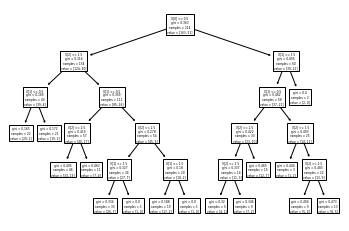

In [78]:
tree.plot_tree(clf)

**Decision Tree Visalization with matplotlib**

In [79]:
import matplotlib.pyplot as plt

[Text(479.53125, 830.5, 'Class <= 0.5\ngini = 0.363\nsamples = 214\nvalue = [163, 51]\nclass = yes'),
 Text(184.0625, 679.5, 'deg-malig <= 1.5\ngini = 0.314\nsamples = 154\nvalue = [124, 30]\nclass = yes'),
 Text(77.5, 528.5, 'menopause <= 0.5\ngini = 0.169\nsamples = 43\nvalue = [39, 4]\nclass = yes'),
 Text(38.75, 377.5, 'gini = 0.165\nsamples = 22\nvalue = [20, 2]\nclass = yes'),
 Text(116.25, 377.5, 'gini = 0.172\nsamples = 21\nvalue = [19, 2]\nclass = yes'),
 Text(290.625, 528.5, 'menopause <= 0.5\ngini = 0.359\nsamples = 111\nvalue = [85, 26]\nclass = yes'),
 Text(193.75, 377.5, 'deg-malig <= 2.5\ngini = 0.419\nsamples = 57\nvalue = [40, 17]\nclass = yes'),
 Text(155.0, 226.5, 'gini = 0.405\nsamples = 46\nvalue = [33, 13]\nclass = yes'),
 Text(232.5, 226.5, 'gini = 0.463\nsamples = 11\nvalue = [7, 4]\nclass = yes'),
 Text(387.5, 377.5, 'deg-malig <= 2.5\ngini = 0.278\nsamples = 54\nvalue = [45, 9]\nclass = yes'),
 Text(310.0, 226.5, 'menopause <= 1.5\ngini = 0.327\nsamples = 34\n

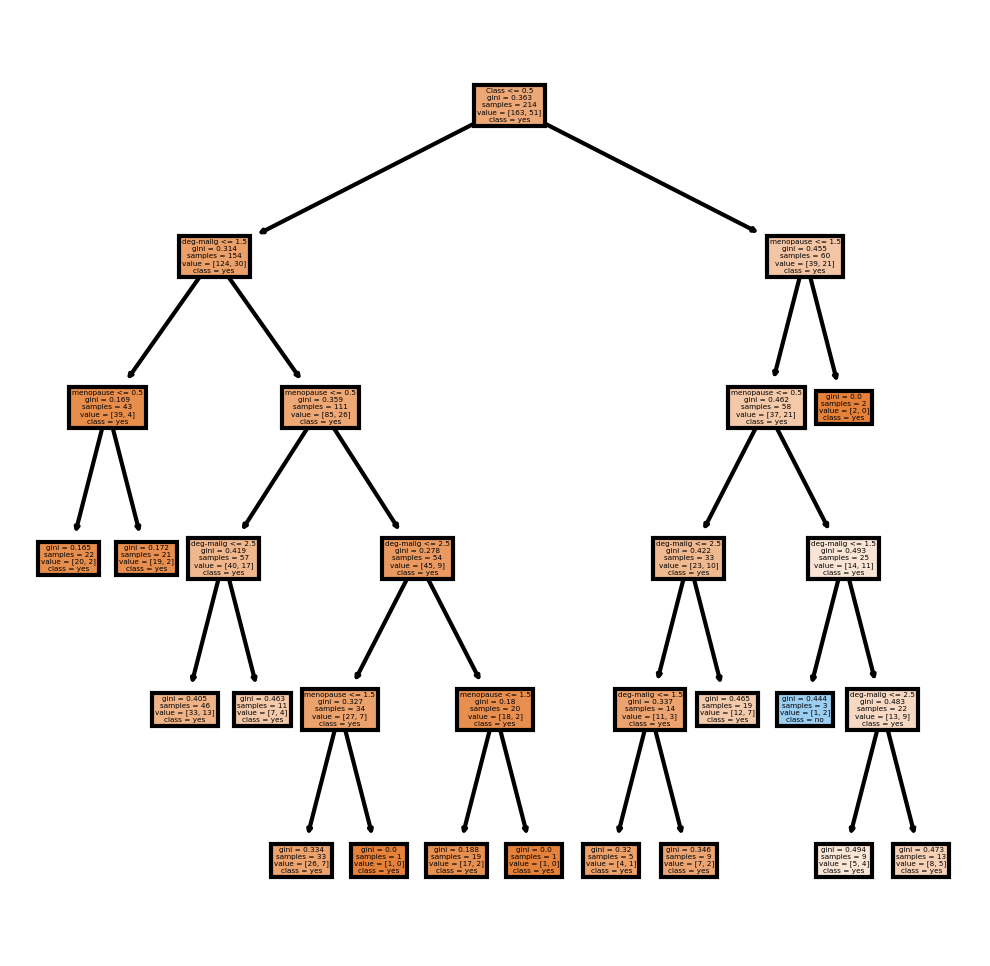

In [80]:
fn=['Class', 'menopause', 'deg-malig']
cn=['yes','no']
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
tree.plot_tree(clf,
               feature_names = fn, 
               class_names=cn,
               filled = True
              )


In [81]:
clf.predict(X_test)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=int64)

## IRIS DATA for Checking

In [110]:
#from sklearn.datasets import load_iris

In [111]:
#iris = load_iris()

In [112]:
#X, y = iris.data, iris.target

In [113]:
#clf = tree.DecisionTreeClassifier()

In [114]:
#clf = clf.fit(X, y)

In [115]:
#tree.plot_tree(clf)

In [116]:
#fn=['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
#cn=['setosa', 'versicolor', 'virginica']
#fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=300)
#tree.plot_tree(clf,
 #              feature_names = fn, 
 #              class_names=cn,
 #              filled = True
 #             )